#### <p style='text-align: justify;'>1. Закон Му́ра (Moore's law) — эмпирическое наблюдение, изначально сделанное Гордоном Муром, согласно которому (в современной формулировке) количество транзисторов, размещаемых на кристалле интегральной схемы, удваивается каждые 24 месяца.<br><br>Ниже приведены данные о числе транзисторов на кристалле. Постройте график изменения числа транзисторов по годам и сделайте у него логарифмическую шкалу по оси ординат (`plt.yscale('log')`).

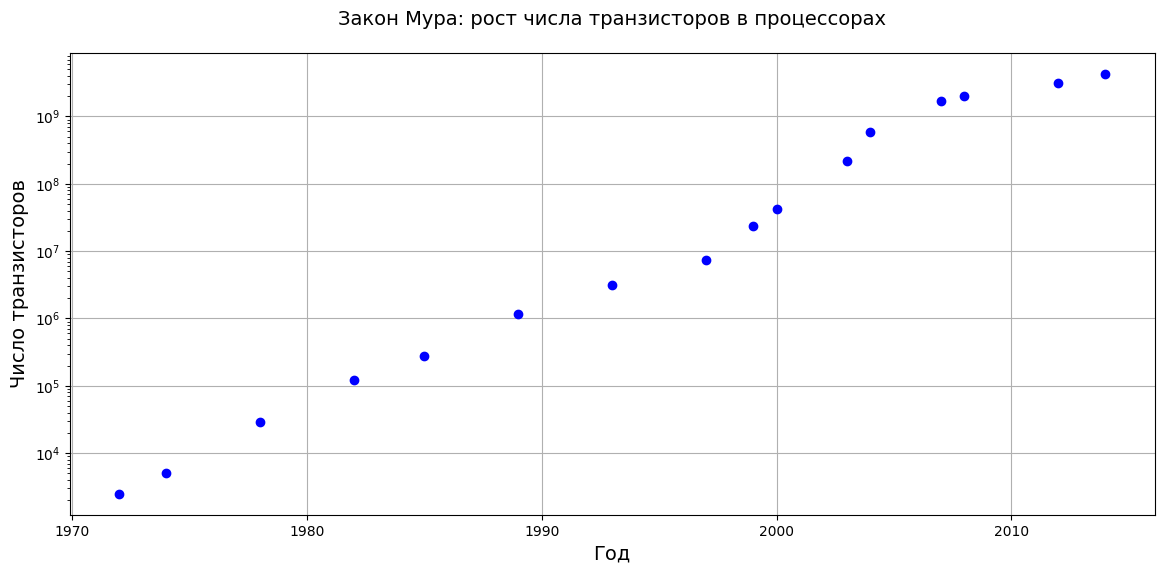

In [24]:
import numpy as np
import matplotlib.pyplot as plt


year = np.array([1972, 1974, 1978, 1982, 1985, 1989, 1993, 1997, 1999, 2000, 2003,
                 2004, 2007, 2008, 2012, 2014])

ntrans = np.array([0.0025, 0.005, 0.029, 0.12, 0.275, 1.18, 3.1, 7.5, 24.0, 42.0,
                   220.0, 592.0, 1720.0, 2046.0, 3100.0, 4310.0]) *10**6 

plt.figure(figsize=(14, 6))
plt.plot(year, ntrans, marker='o', linestyle='none', color='b', label='Число транзисторов')

plt.yscale('log')

plt.title('Закон Мура: рост числа транзисторов в процессорах', fontsize=14, pad=20)
plt.xlabel('Год', fontsize=14)
plt.ylabel('Число транзисторов', fontsize=14)
plt.grid()  

#### <p style='text-align: justify;'>2. Аппроксимируйте полученную в задании № 1 зависимость прямой линией (обратите внимание, что она должна быть прямой линией в логарифмических координатах). Сделайте вывод о соблюдении закона Мура.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
from math import log10 as log

year = np.array([1972, 1974, 1978, 1982, 1985, 1989, 1993, 1997, 1999, 2000, 2003,
                 2004, 2007, 2008, 2012, 2014])

ntrans = np.array([0.0025, 0.005, 0.029, 0.12, 0.275, 1.18, 3.1, 7.5, 24.0, 42.0,
                   220.0, 592.0, 1720.0, 2046.0, 3100.0, 4310.0])  



guess=[1, 1]

def linear(x, k, b):
    return k*x+b
plt.figure(figsize=(14, 6))
ntrans = tuple(map(lambda x: x*1e6, ntrans))
par, cov = opt.curve_fit(linear, year, tuple(map(log, ntrans)), guess)
plt.xlabel('Год')
plt.ylabel('Число транзисторов')
plt.scatter(year, ntrans, label = "moor's law", color='b')
plt.plot(year, tuple(map(lambda x: 10**linear(x, *par), year)), label='approx', color='hotpink')
plt.yscale('log')
plt.grid()
plt.show()
print(log(2) / par)
print(log(2) / par)

ModuleNotFoundError: No module named 'scipy'

#### <p style='text-align: justify;'>3. На сайте https://tylervigen.com/ приведены примеры забавных ложных корреляций. Одним из примеров является ложная корреляция между уровнем разводов в американском штате Мэн и потреблением маргарина на душу населения в США по годам. Два временных ряда здесь имеют разные единицы измерения и значения, поэтому их следует отображать на отдельных осях $y$, имеющих общую ось $x$ (год). Для того, чтобы сделать два подграфика с одинаковой осью $x$, наложенных друг на друга можно воспользоваться функцией `plt.twinx()` по следующей схеме:<br><br>`plt.plot(x, y1)`<br><br>`plt.twinx()`<br><br>`plt.plot(x, y2)`<br><br>Постройте график для указанного примера. Данные приведены ниже:

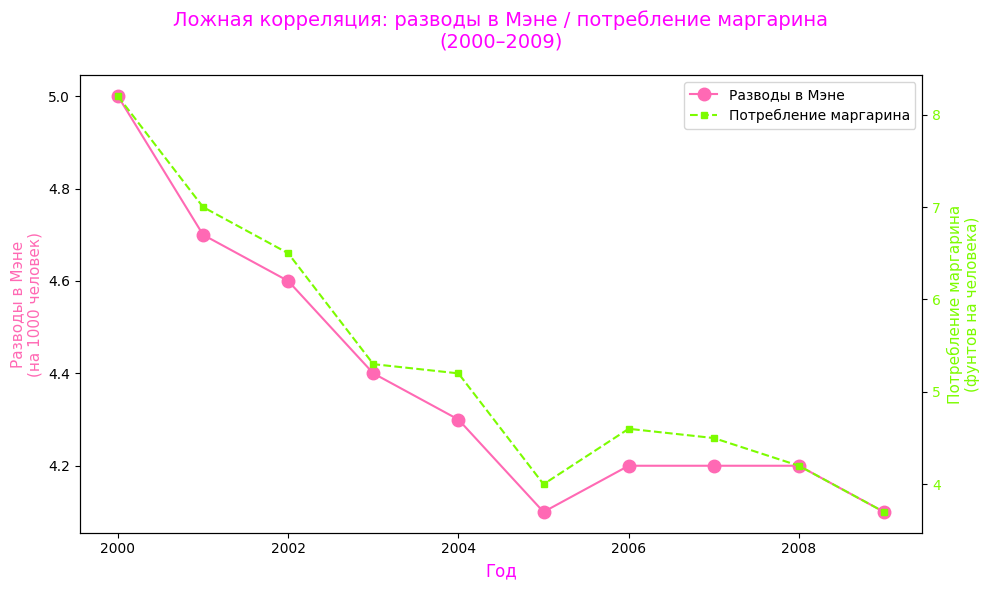

In [37]:

years = range(2000, 2010)
divorce_rate = [5.0, 4.7, 4.6, 4.4, 4.3, 4.1, 4.2, 4.2, 4.2, 4.1]  # разводы на 1000 чел
margarine_consumption = [8.2, 7.0, 6.5, 5.3, 5.2, 4.0, 4.6, 4.5, 4.2, 3.7]  # фунты/чел

fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = 'hotpink'
ax1.set_ylabel('Разводы в Мэне\n(на 1000 человек)', color=color1, fontsize=11)
ax1.plot(years, divorce_rate, color=color1, marker='o', markersize=9,  linestyle='-', label='Разводы в Мэне')
ax1.set_xlabel('Год', fontsize=12, color='magenta')
#ax1.grid()

ax2 = ax1.twinx()

color2 = 'lawngreen'
ax2.plot(years, margarine_consumption, color=color2, marker='s', markersize=5, linestyle='--', label='Потребление маргарина')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylabel('Потребление маргарина\n(фунтов на человека)', color=color2, fontsize=11)


plt.title('Ложная корреляция: разводы в Мэне / потребление маргарина\n(2000–2009)', fontsize=14, pad=20, color="fuchsia")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

fig.tight_layout()
plt.show()

#### <p style='text-align: justify;'>4. Молекула $\mathrm A$ реагирует, образуя либо молекулу $\mathrm B$ либо молекулу $\mathrm C$ по реакциям первого порядка с константами скорости $k_1$ и $k_2$, соответственно. Таким образом, $\frac{d[A]}{dt} = -(k_1 + k_2)[A]$ и тогда $[A] = [A]_0e^{-(k_1+k_2)t}$, где $[A]_0$ — начальная концентрация $\mathrm A$. Концентрации продуктов  (в начальный момент времени равны $0$) растут в пропорции $\frac{[B]}{[C]} = \frac{k_1}{k_2}$ и, согласно уравнению материального баланса $[B] + [C] = [A]_0 - [A]$. Отсюда получается: $$[B] = \frac{k_1}{k_1+k_2}[A]_0\left(1-e^{-(k_1+k_2)t}\right)$$ $$[C] = \frac{k_2}{k_1+k_2}[A]_0\left(1-e^{-(k_1+k_2)t}\right)$$<br>Для пары реакций с $k_1 = 300\:\mathrm{с^{-1}}$ и $k_2 = 100\:\mathrm{с^{-1}}$ постройте кинетические кривые (зависимость концентраций $\mathrm A$, $\mathrm B$ и $\mathrm C$ от времени) в диапазоне времени $0 \leqslant t \leqslant 0.015$, взяв начальную концентрацию реагента $[A]_0 = 2.0\:\mathrm{моль\cdot л^{-1}}$.

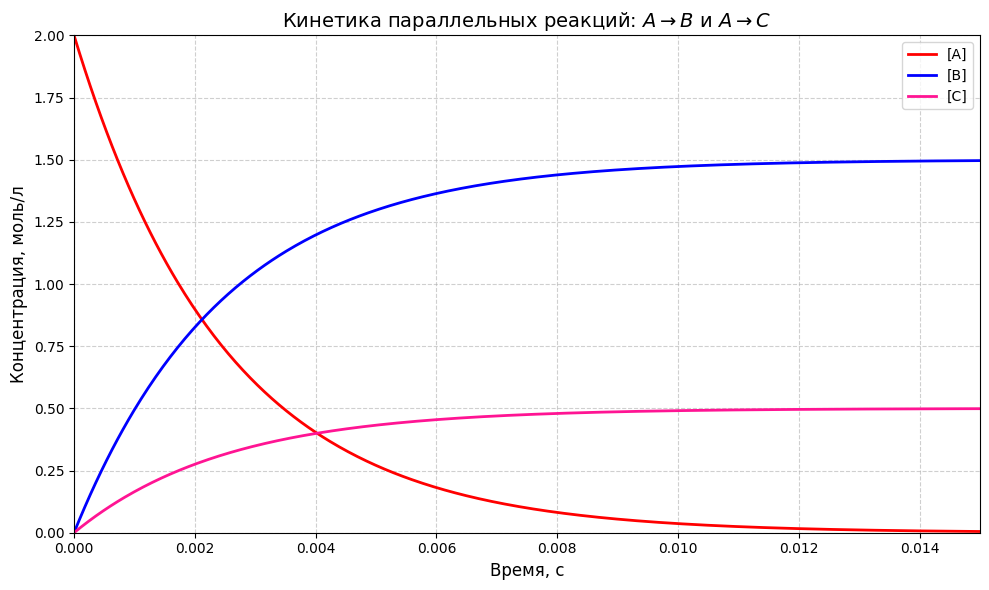

In [ ]:

k1 = 300      # c⁻¹
k2 = 100      # c⁻¹
A0 = 2.0      # моль/л
t_max = 0.015 # с
t = np.linspace(0, t_max, 500) 

k_sum = k1 + k2  # = 400 с⁻¹


A = A0 * np.exp(-k_sum * t)
B = (k1 / k_sum) * A0 * (1 - np.exp(-k_sum * t))
C = (k2 / k_sum) * A0 * (1 - np.exp(-k_sum * t))


plt.figure(figsize=(10, 6))
plt.plot(t, A, label='[A]', color='red', linewidth=2)
plt.plot(t, B, label='[B]', color='blue', linewidth=2)
plt.plot(t, C, label='[C]', color='deeppink', linewidth=2)


plt.title('Кинетика параллельных реакций: $A \\rightarrow B$ и $A \\rightarrow C$', fontsize=14)
plt.xlabel('Время, с', fontsize=12)
plt.ylabel('Концентрация, моль/л', fontsize=12)
plt.legend()
plt.grid(linestyle='--', alpha=0.6)


plt.xlim(0, t_max)
plt.ylim(0, A0)

plt.tight_layout()
plt.show()